# TCGA

The Cancer Genome Atlas (TCGA) is a comprehensive resource that catalogs genomic alterations across 33 different human cancers. Unlike cell lines, TCGA analyzes primary tumor samples directly from patients, providing a detailed view of the tumor's molecular landscape within its native tissue environment. The dataset includes genomic, epigenomic, transcriptomic, and proteomic data but for our analysis we focus on genomic data, in particular on mRNA data and mutations data.


## Roadmap

In this notebook, we will analyze tumor data from **The Cancer Genome Atlas (TCGA)**, a large-scale project that profiles the molecular characteristics of 33 different human cancers using primary tumor samples.

We obtained both expression and mutation data from **cBioPortal** by querying TCGA and downloading the following files:

- `data_mutations.txt`: Contains information about all gene mutations in the samples.  
- `data_mrna_seq_fpkm.txt`: Contains mRNA expression levels in RPKM units, with genes as rows and samples as columns.

### Analysis Pipeline

For the selected cancer studies, we will follow the steps below:

1. **Methodology Overview**  
   - Outline our data processing and filtering strategy.  
   - Describe the rationale behind focusing on mRNA and mutation data.

2. **Sample Analysis**  
   - Perform quality control on patient tumor samples.  
   - Remove outliers or incomplete samples.  
   - Visualize sample-level distributions and characteristics.

3. **Gene Analysis**  
   - Evaluate expression-based QC metrics for genes.  
   - Apply filters to remove uninformative or noisy genes.  
   - Summarize overall gene expression patterns.

4. **Dimensionality Reduction**  
   - Project high-dimensional expression data to 2D space using PCA or t-SNE.  
   - Assess clustering patterns and potential batch effects.

5. **Data Preparation for Classification**  
   - Align mutation and expression data for overlapping samples.  
   - Save the cleaned and preprocessed dataset for downstream classifier training.


## Imports and Auxiliary Functions

In [1]:
import pandas as pd 
import numpy as np 
import os 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.manifold import TSNE
from scipy.stats import skew, kurtosis
from sklearn.decomposition import PCA
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()

In [3]:
# ----------------------
# Violin Plot of Metrics
# ----------------------
def plot_violin_metrics(data, axis):
    """
    Plot violin plots of QC metrics either across genes or samples.
    
    Parameters:
        data (pd.DataFrame): Gene expression matrix (genes x samples)
        axis (int): 0 for sample-wise, 1 for gene-wise
    """
    is_gene_axis = axis == 1
    metrics = {
        "Total Counts": data.sum(axis=axis),
        "Mean": data.mean(axis=axis),
        "Median": data.median(axis=axis),
        "Standard Deviation": data.std(axis=axis),
        "Coefficient of Variation": data.std(axis=axis) / data.mean(axis=axis),
        "Total Features": data.astype(bool).sum(axis=axis)
    }

    fig, ax = plt.subplots(1, len(metrics), figsize=(25, 12))
    colors = ['firebrick', 'steelblue', 'orange', 'darkgreen', 'indigo', 'silver']
    labels = list(metrics.keys())

    for i, (label, values) in enumerate(metrics.items()):
        sns.violinplot(y=values.reset_index(drop=True), ax=ax[i], color=colors[i])
        scope = "Genes" if is_gene_axis else "Samples"
        ax[i].set_title(f"{label} Across {scope}")
        ax[i].set_xlabel('')
        ax[i].grid(True)
        print(f'Max {label.lower()}: {values.max():.2f} - Min: {values.min():.2f} = Range: {(values.max() - values.min()):.2f}')

    plt.tight_layout()
    plt.show()

# ------------------------------------
# Skewness and Kurtosis Distribution
# ------------------------------------
def plot_skewness_kurtosis(data, axis):
    """
    Plot bar plots of skewness and kurtosis across genes or samples.
    
    Parameters:
        data (pd.DataFrame): Gene expression matrix
        axis (int): 0 for sample-wise, 1 for gene-wise
    """
    target = "Sample" if axis == 0 else "Gene"
    skew_vals = data.apply(skew, axis=axis)
    kurt_vals = data.apply(kurtosis, axis=axis)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.bar(range(len(skew_vals)), skew_vals.values, color='mediumpurple')
    plt.title(f"Skewness of Expression per {target}")
    plt.xlabel(f"{target} Index")
    plt.ylabel("Skewness")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.bar(range(len(kurt_vals)), kurt_vals.values, color='darkorange')
    plt.title(f"Excess Kurtosis per {target}")
    plt.xlabel(f"{target} Index")
    plt.ylabel("Kurtosis")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# ---------------------
# Correlation Heatmap
# ---------------------
def heatmap_plot(title, data, samples):
    """
    Plot correlation heatmap across a list of sample IDs.

    Parameters:
        title (str): Title of the heatmap
        data (pd.DataFrame): Expression matrix
        samples (list): Sample IDs to include
    """
    plt.figure(figsize=(10, 8))
    plt.title(title)
    sns.heatmap(data.loc[:, samples].corr(), cmap='viridis', fmt='.01f')
    plt.tight_layout()
    plt.show()
    print(f"Number of samples plotted: {len(samples)} x {len(samples)}")

# ------------------------------
# PCA and t-SNE Visualization
# ------------------------------
def plot_PCA_tsne(data_ordered,mutated_samples,non_mutated_samples, title):

    mutation_status = ['Mutated']*len(mutated_samples) + ['Non_Mutated']*len(non_mutated_samples)
    label_map = {'Mutated': 0, 'Non_Mutated': 1}
    color_values = [label_map[label] for label in mutation_status]

    # Perform PCA (reduce to 2 components)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(data_ordered.T.to_numpy())

    # Perform t-SNE (reduce to 2 components)
    tsne = TSNE(n_components=2, random_state=42)
    tsne_result = tsne.fit_transform(data_ordered.T.to_numpy())

    # Plot PCA
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.scatter(pca_result[:, 0], pca_result[:, 1], c=color_values, cmap='viridis')
    plt.title('PCA: Mutated vs Non-Mutated')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.grid(True)
    plt.legend(['Mutated', 'Non_Mutated'], loc='upper right')

    # Plot t-SNE
    plt.subplot(1, 2, 2)
    plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=color_values, cmap='viridis')
    plt.title('t-SNE: Mutated vs Non-Mutated')
    plt.xlabel('tSNE1')
    plt.ylabel('tSNE2')
    plt.grid(True)
    plt.legend(['Mutated', 'Non_Mutated'], loc='upper right')


    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------
# Violin Plot of Mitochondrial Gene Percentage
# ---------------------------------------------
def plot_MT_percent_violinplot(data):
    """
    Plot the percentage of mitochondrial gene expression per sample.

    Parameters:
        data (pd.DataFrame): Gene expression matrix (genes x samples)
    """
    total_expr = data.sum(axis=0)
    mt_expr = data.loc[data.index.str.startswith("MT-")].sum(axis=0)
    mt_percent = (mt_expr / total_expr) * 100

    plt.figure(figsize=(12, 6))
    sns.violinplot(y=mt_percent, color='skyblue')
    plt.title("Violin Plot of Mitochondrial Gene Expression (%) per Sample")
    plt.ylabel("Mitochondrial % of Total RPKM")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Data Collection

In [4]:
mRNA_path = '../DATA/tcga/data_mrna_seq_fpkm.txt'
mRNA = pd.read_csv(mRNA_path, sep='\t', comment='#')
mut_path = '../DATA/tcga/data_mutations.txt'
mut_all = pd.read_csv(mut_path, sep='\t', comment='#')

In [5]:
mRNA.head()

,Hugo_Symbol,SP89389,SP21193,SP13206,SP103623,SP32742,SP111095,SP8394,SP87446,SP36586,...,SP15656,SP123888,SP59420,SP116679,SP1377,SP16269,SP122676,SP88776,SP64546,SP21057
0,TSPAN6,65.515874,93.507754,15.155525,9.751670,16.048850,22.724550,29.154328,18.058406,15.486367,...,0.000000,27.329458,3.633029,2.302684,227.790781,0.007476,9.736614,29.283034,28.045150,62.010994
1,TNMD,0.046881,0.655002,0.000000,0.188735,0.014542,0.000000,0.110858,0.031887,0.000000,...,0.000000,0.033938,0.064275,0.414507,0.345589,0.000000,0.062405,0.000000,0.026696,0.405261
2,DPM1,63.315522,23.608843,42.136192,14.507132,45.302557,24.728471,22.578201,21.447736,19.492883,...,18.197652,38.290606,35.459968,31.888606,34.589654,23.290497,31.444337,23.118048,51.549932,30.790944
3,SCYL3,2.222857,1.933762,2.318698,2.342167,4.373694,4.050503,3.372809,2.359359,1.930601,...,4.735389,1.356212,4.340347,5.257385,2.496924,6.466530,1.072155,3.699246,1.989817,3.313589
4,C1orf112,2.565836,1.861716,2.870440,0.454312,4.125029,1.877498,1.999630,0.747373,0.501911,...,6.592257,0.259415,1.864762,2.262558,1.257206,6.384945,1.207673,0.539174,1.556905,1.757992


In [6]:
mut_all.head()

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSc,HGVSp,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Hotspot,Annotation_Status,DNA_VAF
0,MATN1,4146.0,NaN,GRCh37,1,31189041,31189041,+,missense_variant,Missense_Mutation,...,ENST00000373765.4:c.922T>C,p.Ser308Pro,p.S308P,ENST00000373765,NM_002379.3,308.0,Tca/Cca,0,SUCCESS,0.1190
1,TFAP2E,339488.0,NaN,GRCh37,1,36055608,36055608,+,missense_variant,Missense_Mutation,...,ENST00000373235.3:c.863G>A,p.Arg288His,p.R288H,ENST00000373235,NM_178548.3,288.0,cGc/cAc,0,SUCCESS,0.0851
2,FGGY,55277.0,NaN,GRCh37,1,60228203,60228203,+,synonymous_variant,Silent,...,ENST00000303721.7:c.1603C>T,p.Leu535=,p.L535=,ENST00000303721,NM_018291.3,535.0,Ctg/Ttg,0,SUCCESS,0.4103
3,PGM1,5236.0,NaN,GRCh37,1,64125315,64125315,+,missense_variant,Missense_Mutation,...,ENST00000371084.3:c.1658C>T,p.Thr553Met,p.T553M,ENST00000371084,NM_002633.2,553.0,aCg/aTg,0,SUCCESS,0.1400
4,DEPDC1,55635.0,NaN,GRCh37,1,68948436,68948436,+,missense_variant,Missense_Mutation,...,ENST00000456315.2:c.1055G>T,p.Arg352Ile,p.R352I,ENST00000456315,NM_001114120.1,352.0,aGa/aTa,0,SUCCESS,0.1765


In [7]:
mRNA.set_index('Hugo_Symbol', inplace=True)

# Merge duplicate genes by averaging expression values
mRNA = mRNA.groupby(mRNA.index).mean()

# Filter only TP53 mutations
mut_all = mut_all[mut_all['Hugo_Symbol'] == 'TP53']

# Keep only sample ID and mutation type
mut_all = mut_all[['Tumor_Sample_Barcode', 'Variant_Type']]
mut_all.set_index('Tumor_Sample_Barcode', inplace=True)

# --------- Filter Inconsistent Mutation Annotations ---------
variant_check = mut_all.groupby(mut_all.index)["Variant_Type"].nunique()
consistent_samples = variant_check[variant_check == 1].index
inconsistent_samples = variant_check[variant_check != 1].index

# Keep only consistent mutation samples
mut_all = mut_all.loc[consistent_samples]

# Drop inconsistent samples from mRNA data
mRNA = mRNA.drop(columns=[col for col in inconsistent_samples if col in mRNA.columns])

# Remove duplicates (keep one mutation type per sample)
mut_all = mut_all[~mut_all.index.duplicated(keep='first')]

# --------- Create Wild-Type (WT) Annotations ---------
all_samples = set(mRNA.columns)
mutated_samples = set(mut_all.index)
wt_samples = all_samples - mutated_samples

# Assign 'WT' to those samples
wt_df = pd.DataFrame(index=list(wt_samples))
wt_df['Variant_Type'] = 'WT'

# Combine WT and Mutated samples
mut_all = pd.concat([mut_all, wt_df])

# Reorder to match mRNA sample columns
mut_all = mut_all.loc[mRNA.columns]

# --------- Final Output (Optional) ---------
# You now have:
# - `mRNA`: gene expression matrix (genes x samples)
# - `mut_all`: TP53 mutation status per sample (with 'WT')

# Example: inspect how many samples are WT vs Mutated
print(mut_all['Variant_Type'].value_counts())


Variant_Type
WT     803
SNP    331
DEL     46
INS     18
DNP      5
Name: count, dtype: int64


In [8]:
print(f'Zero entries: {(mRNA == 0).sum().sum()}') # entries all positive no zeros
print("The sparsity of the data is due to the fact that the technique used to measure the expression is bulk RNAseq")

Zero entries: 28785531
The sparsity of the data is due to the fact that the technique used to measure the expression is bulk RNAseq


## Filtering

### Samples

Max total counts: 4252383.31 - Min: 221125.11 = Range: 4031258.20
Max mean: 76.14 - Min: 3.96 = Range: 72.18
Max median: 0.82 - Min: 0.00 = Range: 0.82
Max standard deviation: 9591.48 - Min: 26.98 = Range: 9564.50
Max coefficient of variation: 125.97 - Min: 6.62 = Range: 119.36
Max total features: 51945.00 - Min: 20701.00 = Range: 31244.00


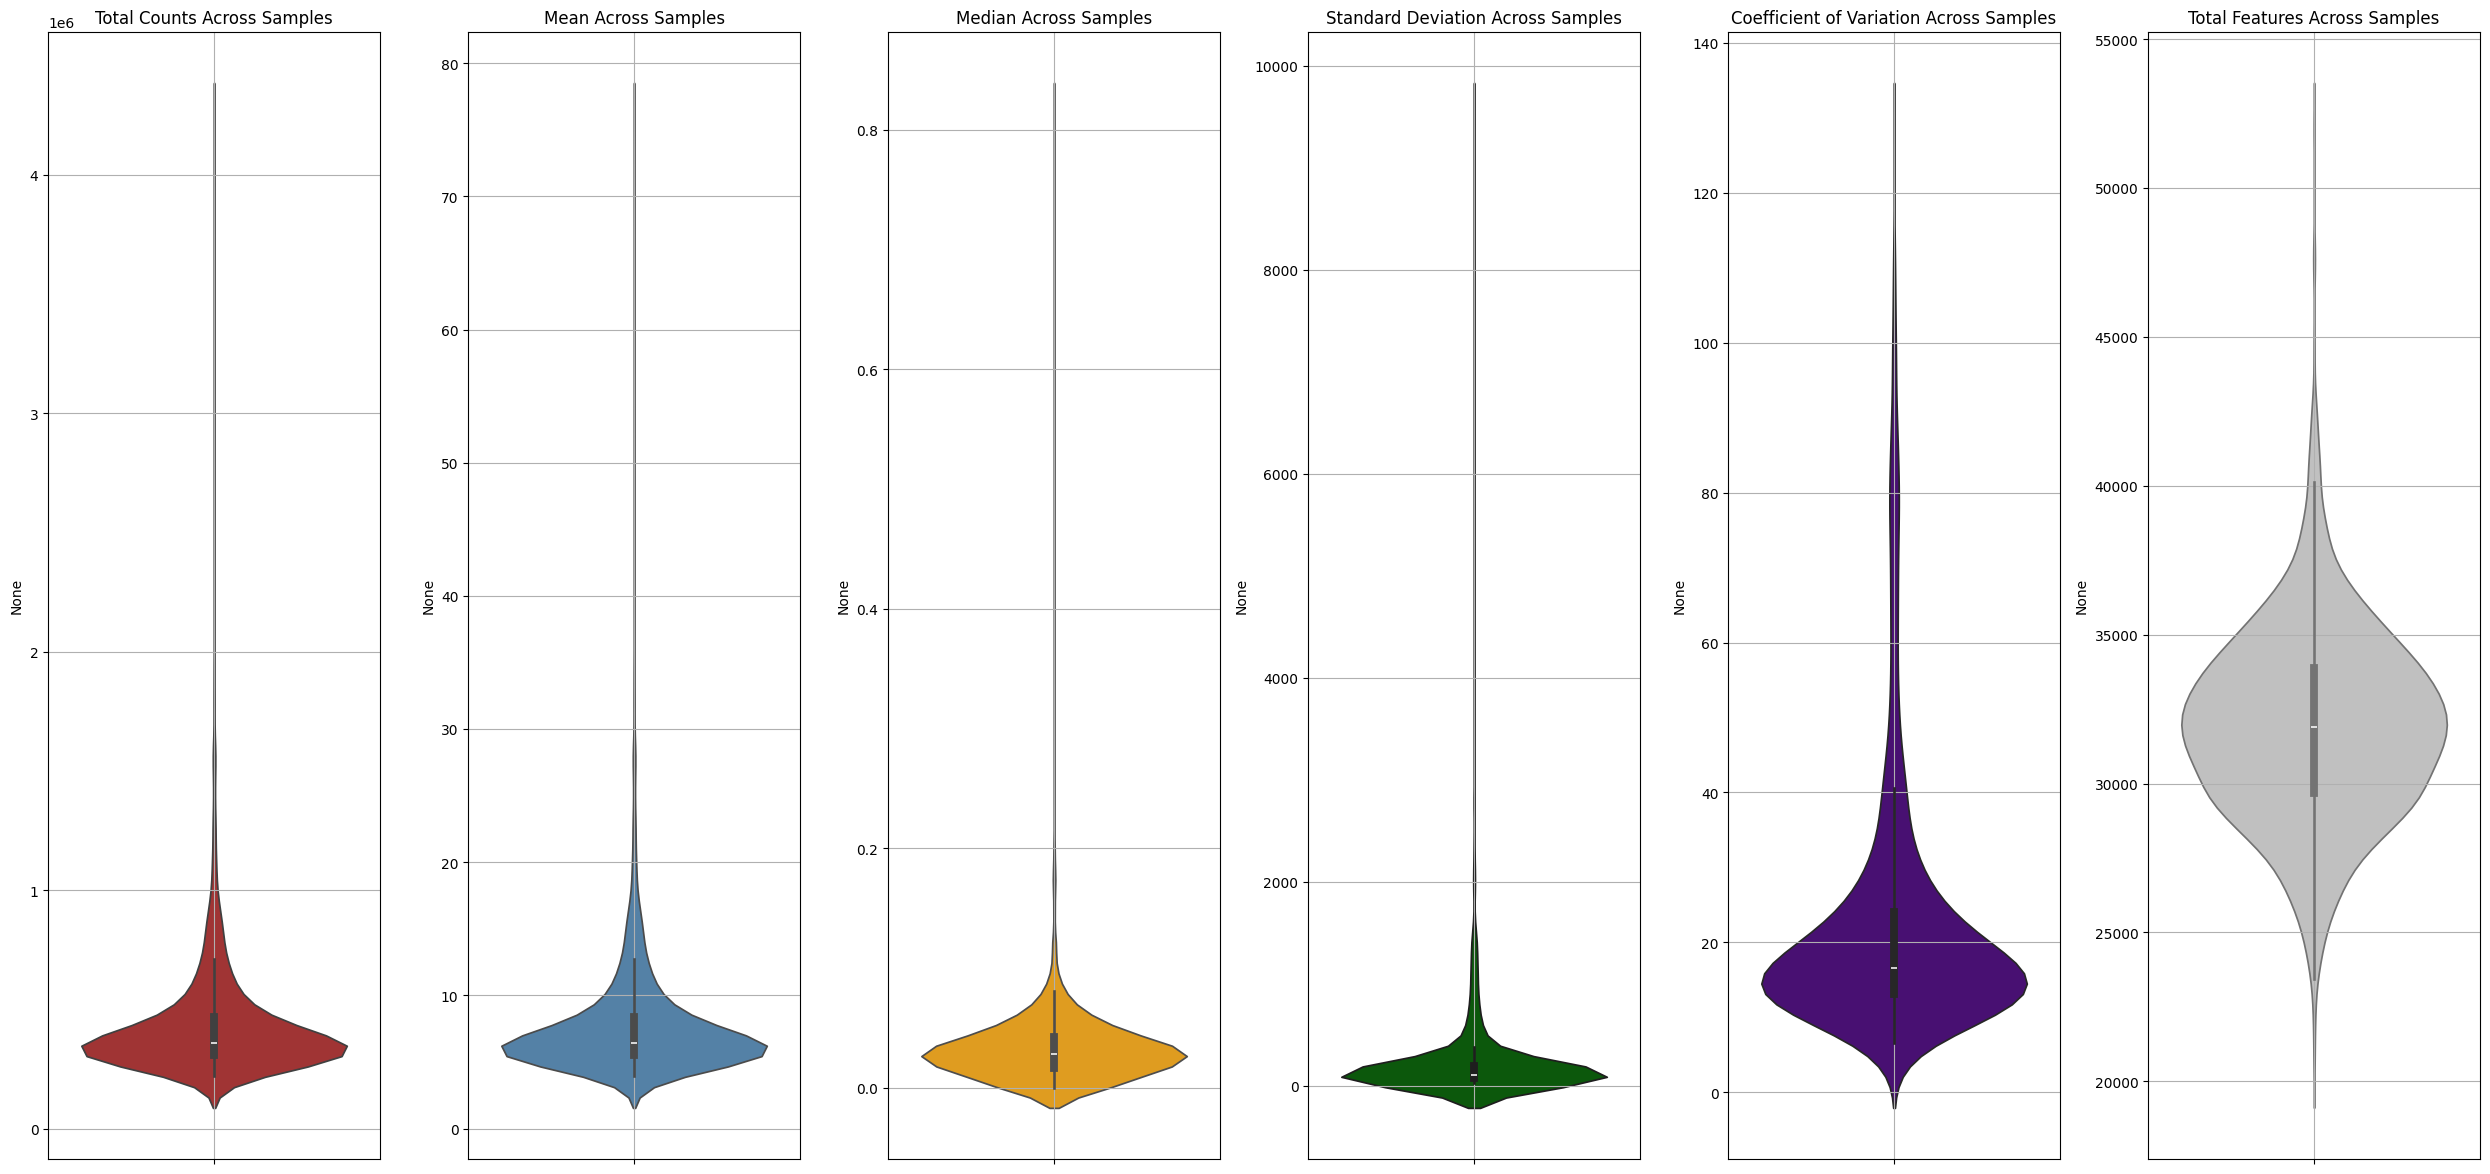

In [9]:
#Violin metrics across sample 
plot_violin_metrics(mRNA,axis = 0)

In [10]:
corr_matrix_micro = mRNA.corr()

In [11]:
print('-----mRNA data matrix-----')
print('Minimum correlation between samples:',corr_matrix_micro.describe().loc['min'].min())
print('Minimum mean correlation between samples:',corr_matrix_micro.describe().loc['mean'].min())

-----mRNA data matrix-----
Minimum correlation between samples: 0.0010921323216801278
Minimum mean correlation between samples: 0.06338340175719509


In [12]:
mutated_samples = mut_all[mut_all['Variant_Type'] != 'WT'].index
non_mutated_samples = mut_all[mut_all['Variant_Type'] == 'WT'].index


random_samples_mut_100 = np.random.choice(mutated_samples,size = 100)
random_samples_non_mut_100 = np.random.choice(non_mutated_samples,size = 100)
random_samples_mut_50_non_mut50 = list(random_samples_mut_100[:50]) + list(random_samples_non_mut_100[:50])

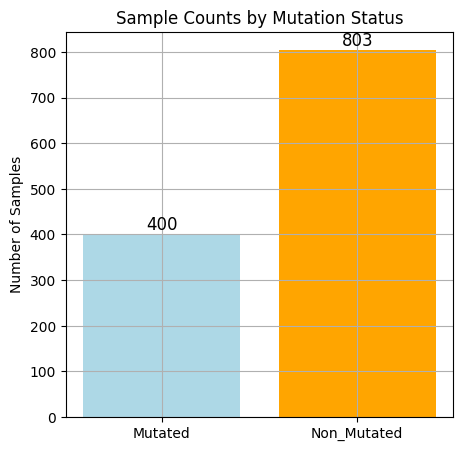

In [13]:
# See mutated distribution
counts = [len(mutated_samples), len(non_mutated_samples)]

plt.figure(figsize = (5,5))
plt.bar(x=['Mutated', 'Non_Mutated'], height=counts, 
                            color=['lightblue', 'orange'])

# Add text labels on top of each bar
for i, count in enumerate(counts):
    plt.text(i, count + 1, str(count), ha='center', va='bottom', fontsize=12)

plt.grid(True)
plt.ylabel("Number of Samples")
plt.title("Sample Counts by Mutation Status")
plt.show()

This section visualizes the correlation structure within a subset of the data by randomly selecting 100 **mutated** and 100 **non-mutated** samples. The goal is to assess whether the **intra-class correlations** are strong and distinct enough to be visually apparent.

Specifically, the analysis compares the correlation values computed **within each class** (mutated or non-mutated) against those obtained from the **entire dataset**, in order to determine whether class-specific expression patterns emerge.


In [14]:
# Extracting a random sample of mutated and non mutated data
random_samples_mut_100 = np.random.choice(mutated_samples,size = 100)
random_samples_non_mut_100 = np.random.choice(non_mutated_samples,size = 100)

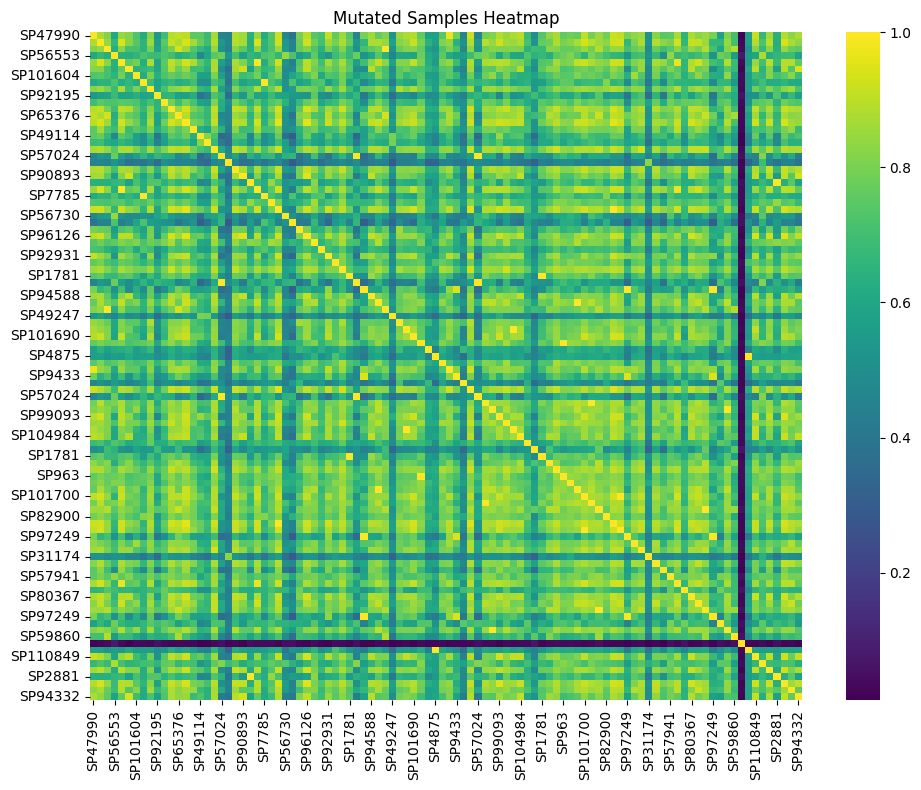

Number of samples plotted: 100 x 100


In [15]:
heatmap_plot(title = 'Mutated Samples Heatmap',data=mRNA,samples = random_samples_mut_100)

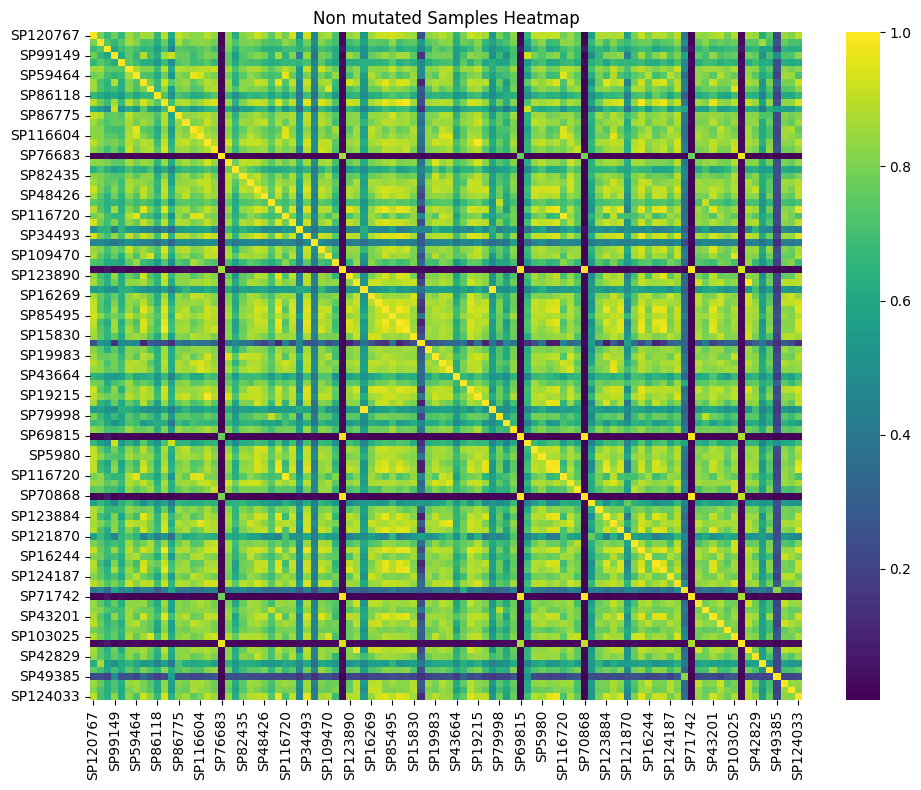

Number of samples plotted: 100 x 100


In [16]:
heatmap_plot(title = 'Non mutated Samples Heatmap',data=mRNA,samples = random_samples_non_mut_100)

In [17]:
# --- Correlation Analysis by Mutation Status ---

def print_min_correlation_stats(group_name, sample_ids, data):
    corr_matrix = data.loc[:, sample_ids].corr()
    stats = corr_matrix.describe()

    min_corr = stats.loc['min'].min()
    min_mean_corr = stats.loc['mean'].min()

    print(f"---- {group_name} Samples ----")
    print(f"1) Minimum pairwise correlation: {min_corr:.4f}")
    print(f"2) Minimum average correlation per sample: {min_mean_corr:.4f}\n")

# Mutated samples
print_min_correlation_stats("Mutated", mutated_samples, mRNA)

# Non-mutated samples
print_min_correlation_stats("Non-Mutated", non_mutated_samples, mRNA)


---- Mutated Samples ----
1) Minimum pairwise correlation: 0.0052
2) Minimum average correlation per sample: 0.0316

---- Non-Mutated Samples ----
1) Minimum pairwise correlation: 0.0011
2) Minimum average correlation per sample: 0.0857



Mutated samples tend to be more highly correlated with each other than the non-mutated samples.

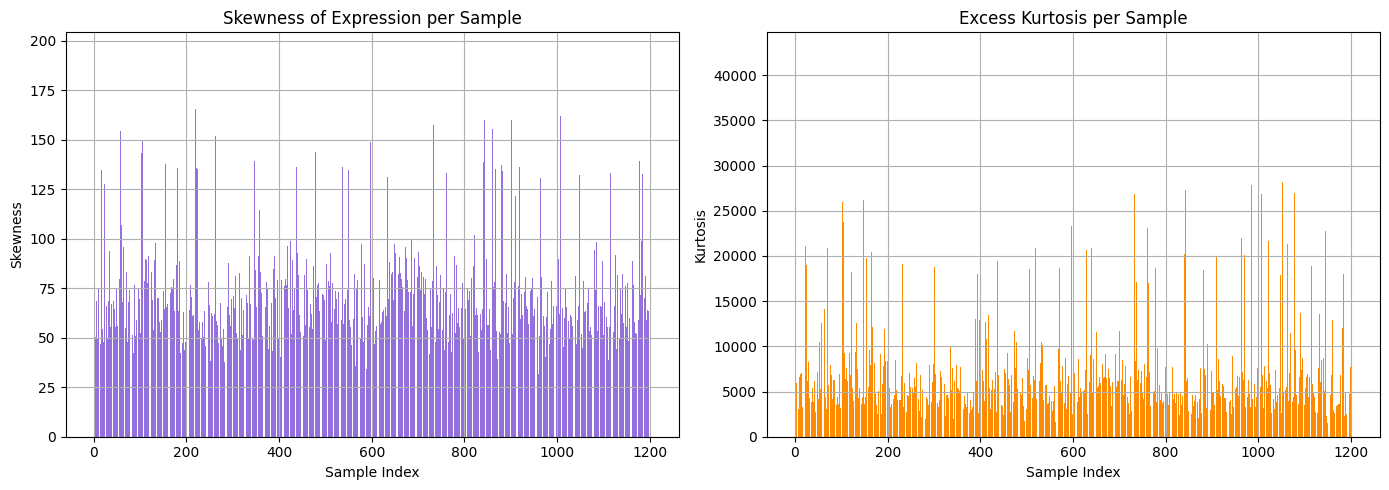

In [18]:
plot_skewness_kurtosis(data=mRNA,axis = 0)

#### Skewness and Kurtosis Results

In this dataset, both **skewness** and **excess kurtosis** are positive across samples.

This indicates that the gene expression distributions are generally **right-skewed** and exhibit **sharper peaks with heavier tails** than a normal distribution. Such patterns are consistent with typical RNA-seq data, particularly in raw or RPKM-normalized form, and highlight the need for appropriate transformation or normalization in downstream analyses.


### Genes

Max total counts: 17807169.38 - Min: 0.00 = Range: 17807169.38
Max mean: 14802.30 - Min: 0.00 = Range: 14802.30
Max median: 7129.94 - Min: 0.00 = Range: 7129.94
Max standard deviation: 79947.29 - Min: 0.00 = Range: 79947.29
Max coefficient of variation: 34.68 - Min: 0.27 = Range: 34.42
Max total features: 1203.00 - Min: 0.00 = Range: 1203.00


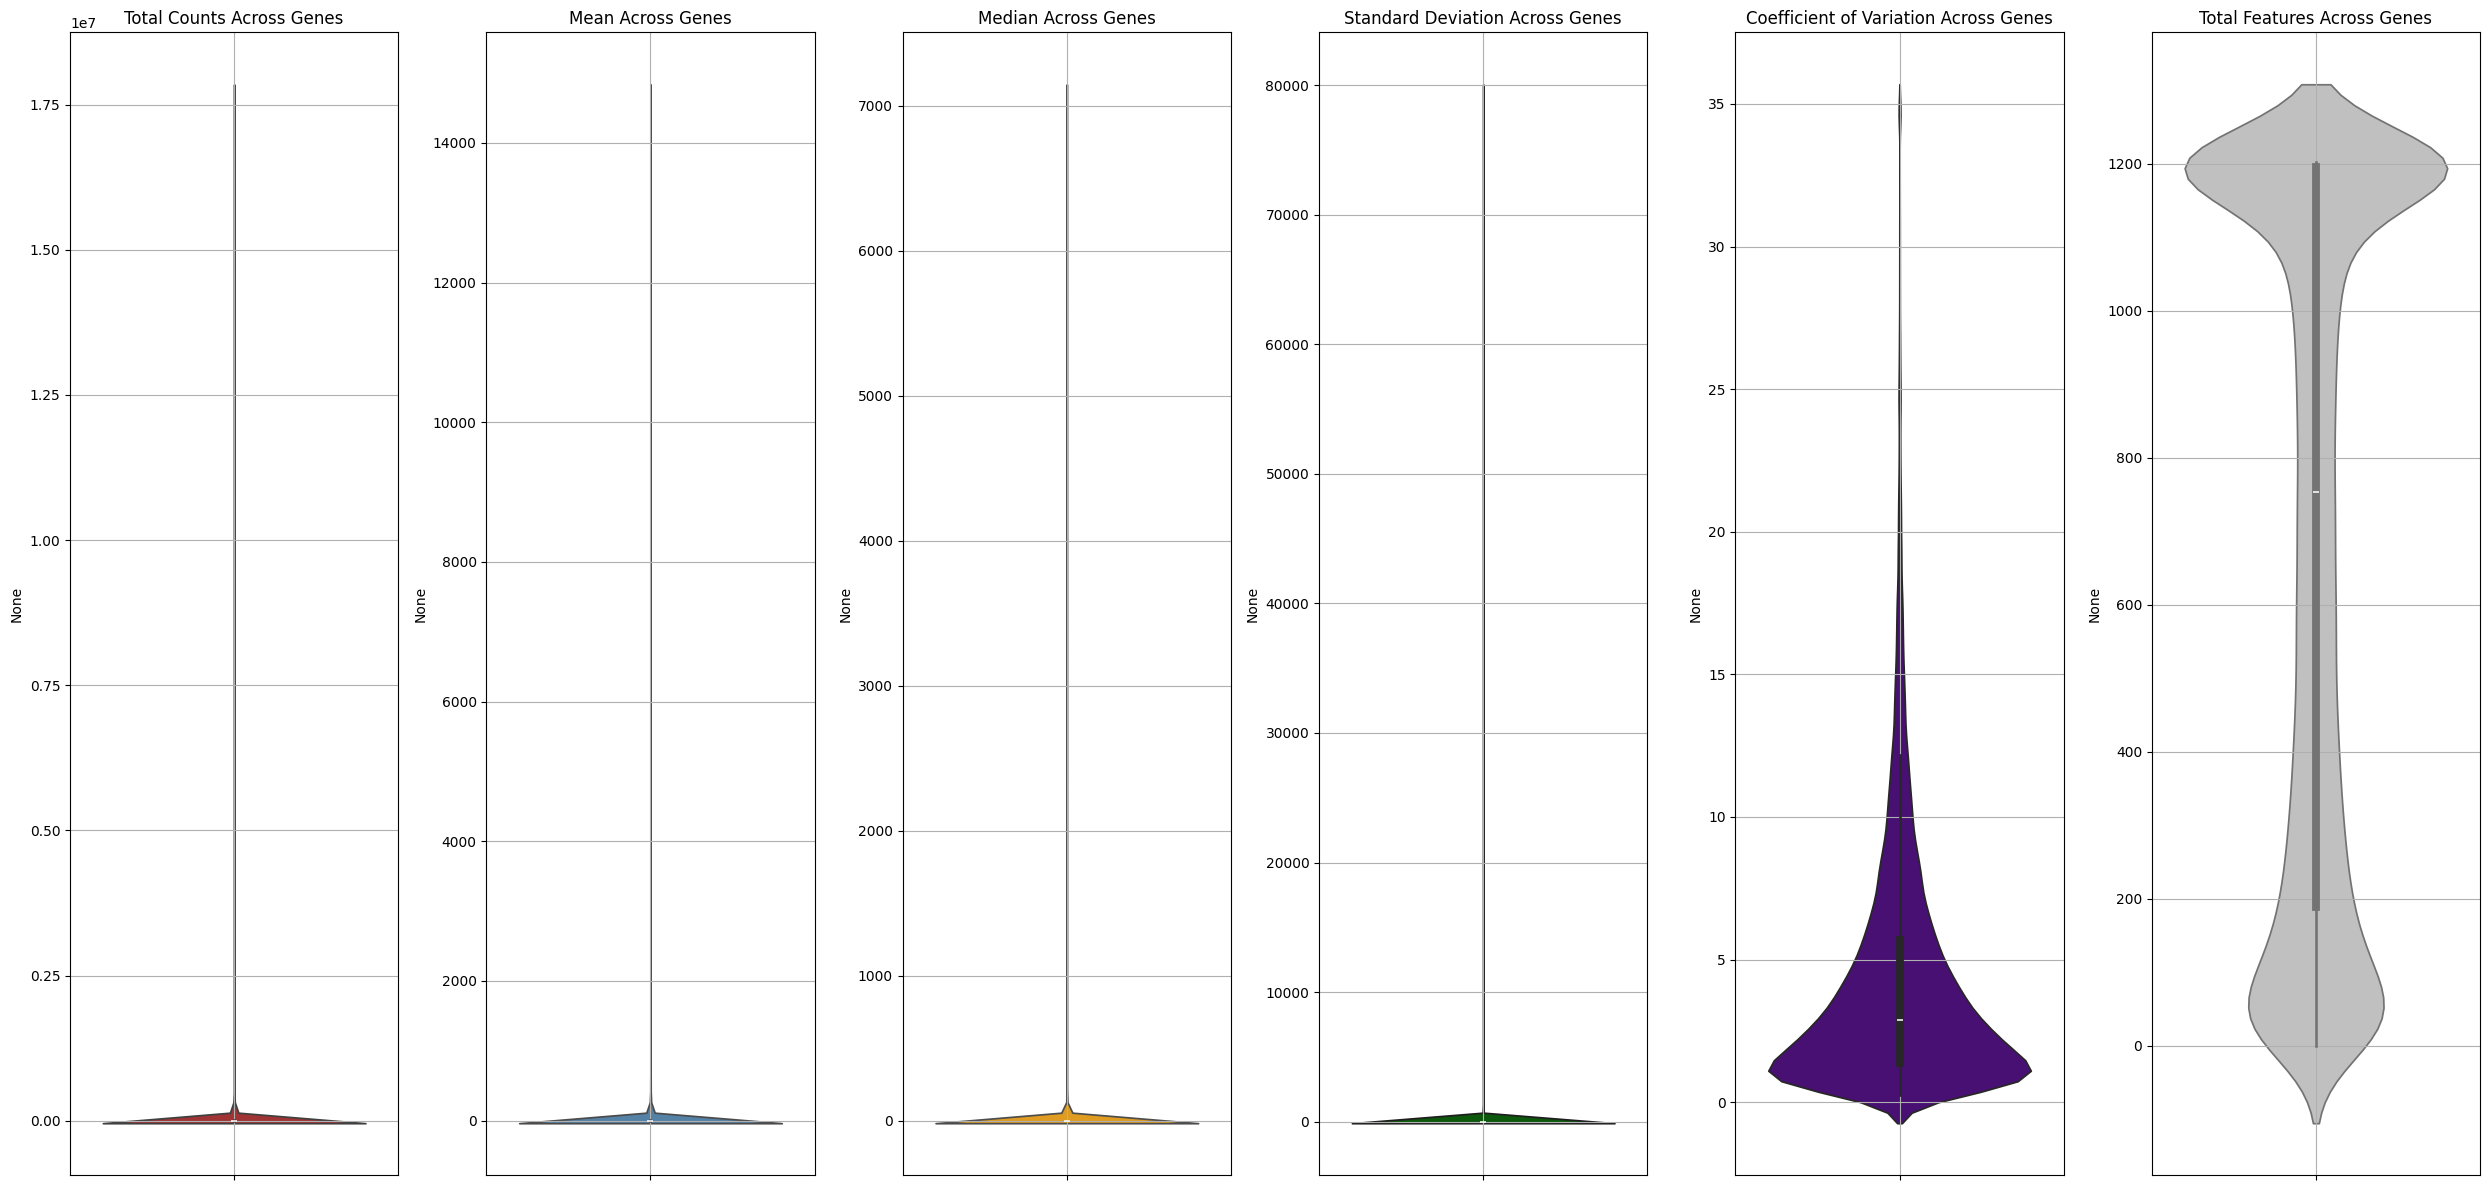

In [19]:
# Violin metrics per gene 
plot_violin_metrics(mRNA,axis = 1)

The **coefficient of variation (CV)** shows substantial variability across genes, ranging from ~0.27 to ~34.7. This wide spread indicates that some genes have **nearly constant expression**, while others exhibit **extreme variation** relative to their mean expression levels.

Such extremes can introduce noise or reduce the robustness of downstream analyses. Therefore, it is appropriate to apply a **filtering step** to remove genes with **very low or very high CV**, retaining only those with a moderate and informative level of variation.


In [20]:
# Filter out genes with a coefficient of variation less than 5%
# If gene expression does not vary much compared to the mean, then it is probably less significant to our analysis.

cv_genes = mRNA.std(axis = 1)/mRNA.mean(axis = 1) 
genes_to_keep = cv_genes[(cv_genes > 0.05) & (cv_genes< 50)].index

# remove
mRNA_final = mRNA.loc[genes_to_keep]

We can now see if filtering has had a significant impact on the samples and genes.

Max total counts: 17807169.38 - Min: 0.00 = Range: 17807169.37
Max mean: 14802.30 - Min: 0.00 = Range: 14802.30
Max median: 7129.94 - Min: 0.00 = Range: 7129.94
Max standard deviation: 79947.29 - Min: 0.00 = Range: 79947.29
Max coefficient of variation: 34.68 - Min: 0.27 = Range: 34.42
Max total features: 1203.00 - Min: 1.00 = Range: 1202.00


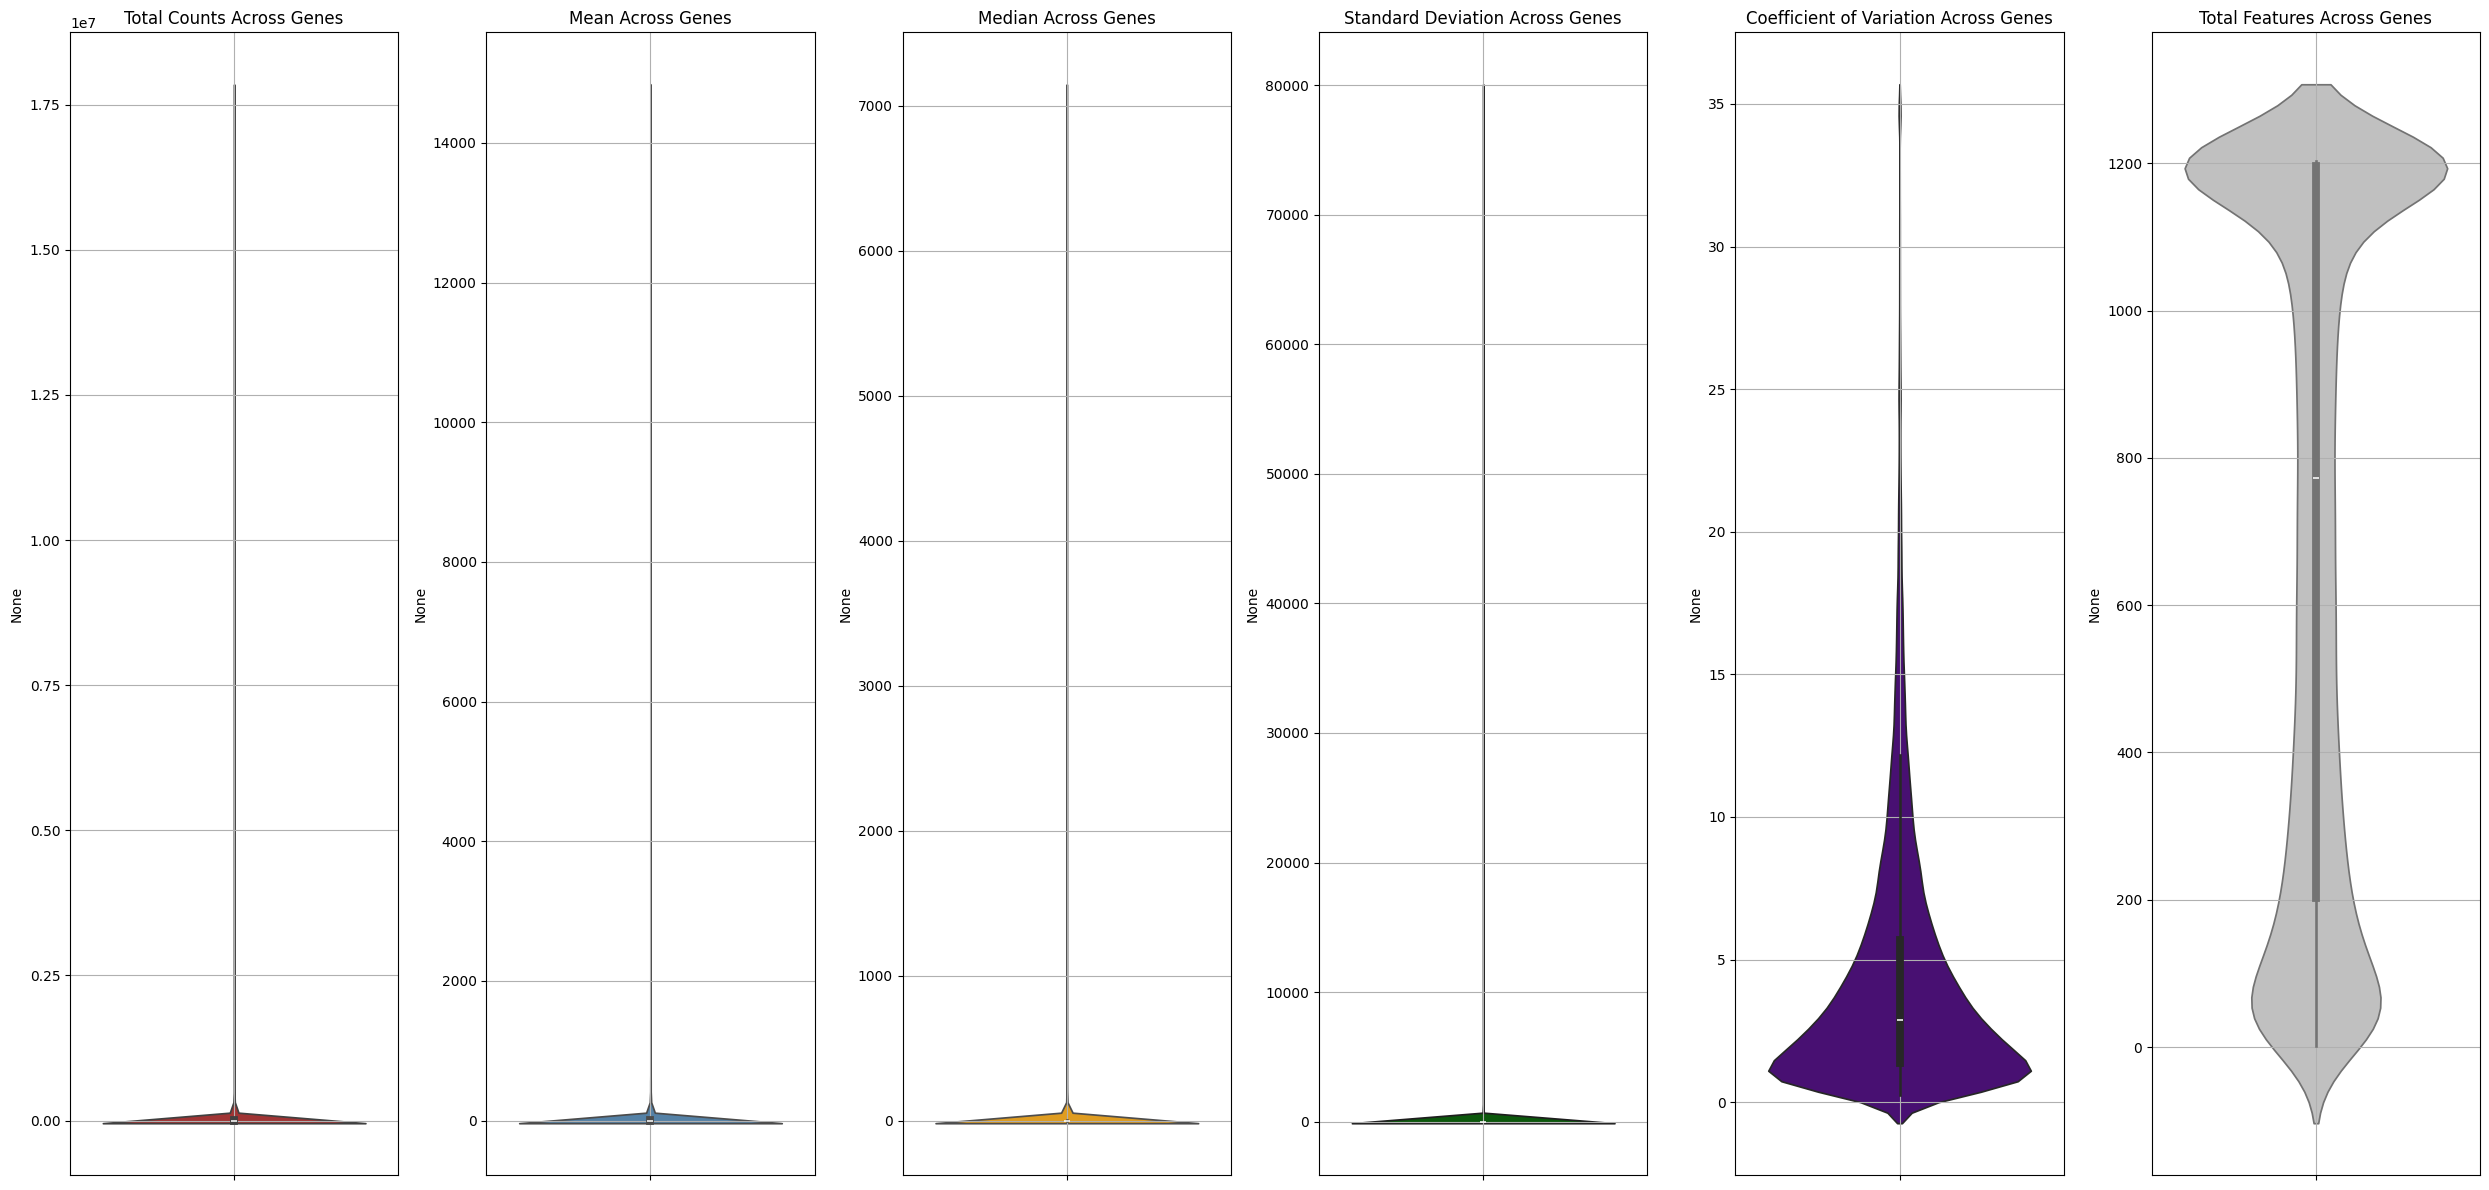

In [21]:
plot_violin_metrics(mRNA_final,axis = 1)

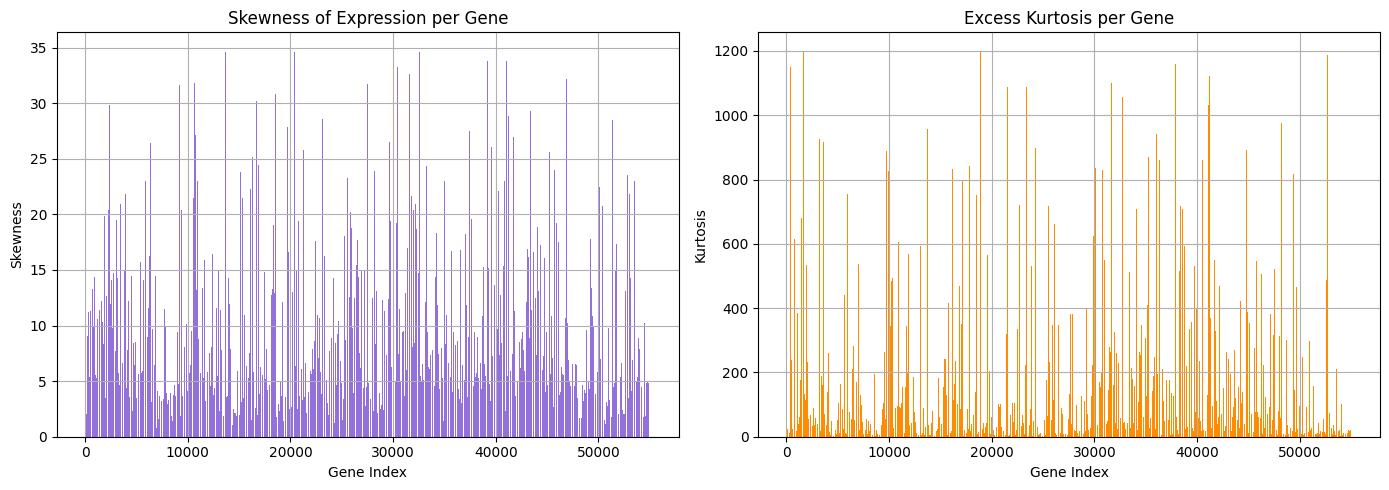

In [22]:
plot_skewness_kurtosis(mRNA_final,axis = 1)

Max total counts: 4252383.31 - Min: 221125.11 = Range: 4031258.20
Max mean: 77.20 - Min: 4.01 = Range: 73.19
Max median: 0.83 - Min: 0.00 = Range: 0.83
Max standard deviation: 9658.20 - Min: 27.17 = Range: 9631.04
Max coefficient of variation: 125.10 - Min: 6.57 = Range: 118.53
Max total features: 51945.00 - Min: 20701.00 = Range: 31244.00


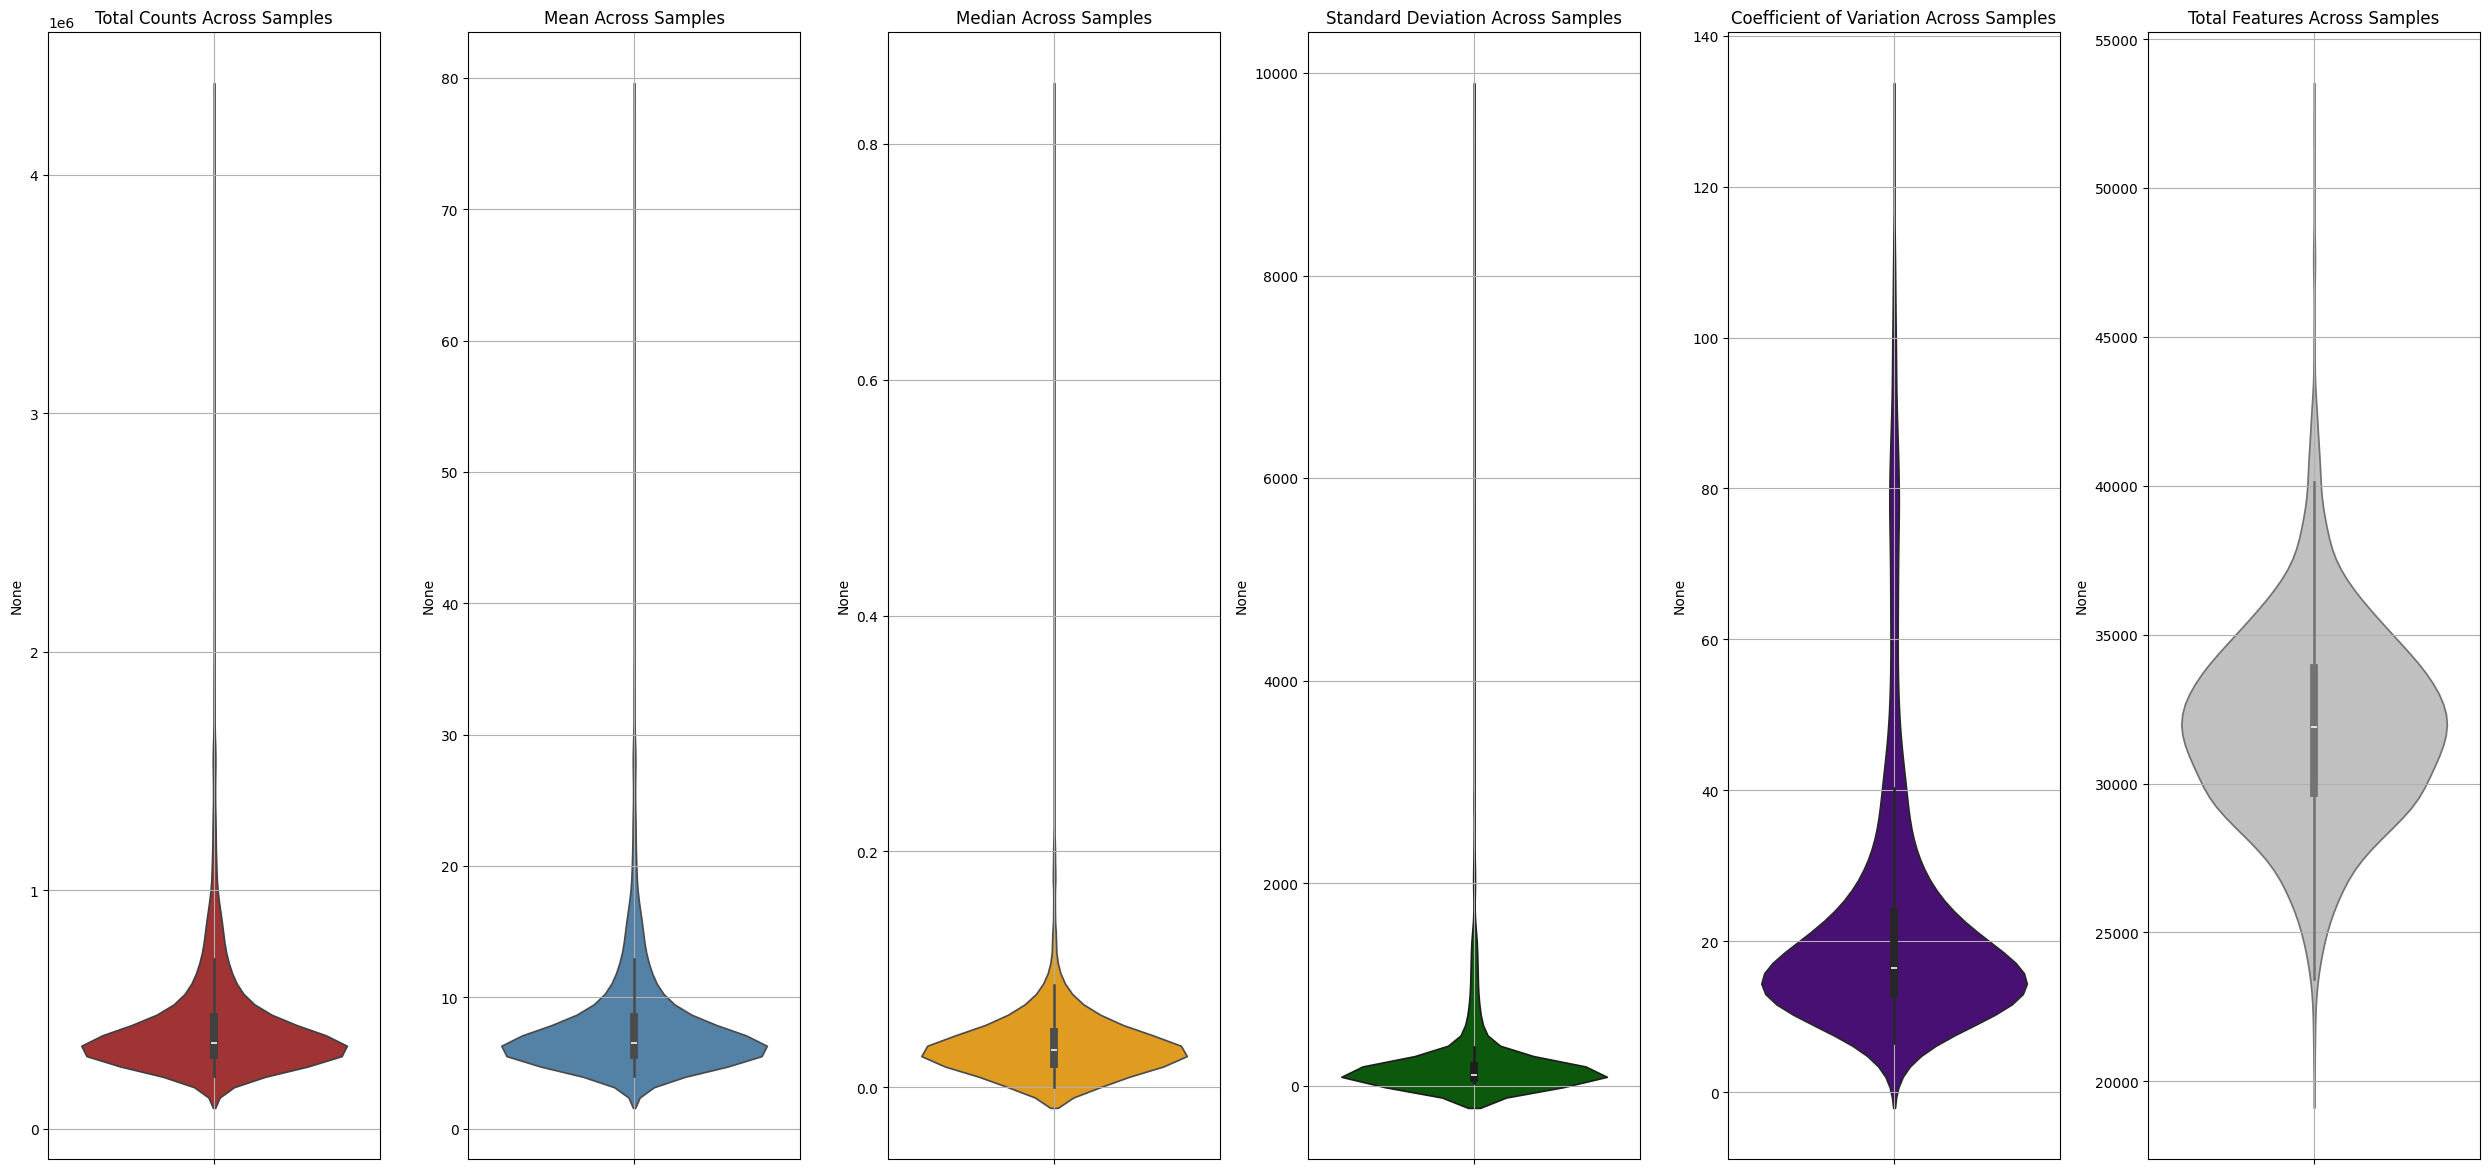

In [23]:
# See how it affected the samples
plot_violin_metrics(mRNA_final,axis = 0)

## Dimensionality Reduction

This section applies dimensionality reduction techniques to visualize the structure of the data and assess whether **mutated** and **non-mutated** samples exhibit any meaningful separation in lower-dimensional space.


In [24]:
mRNA_data_all = mRNA_final[mutated_samples.tolist() + non_mutated_samples.tolist()]

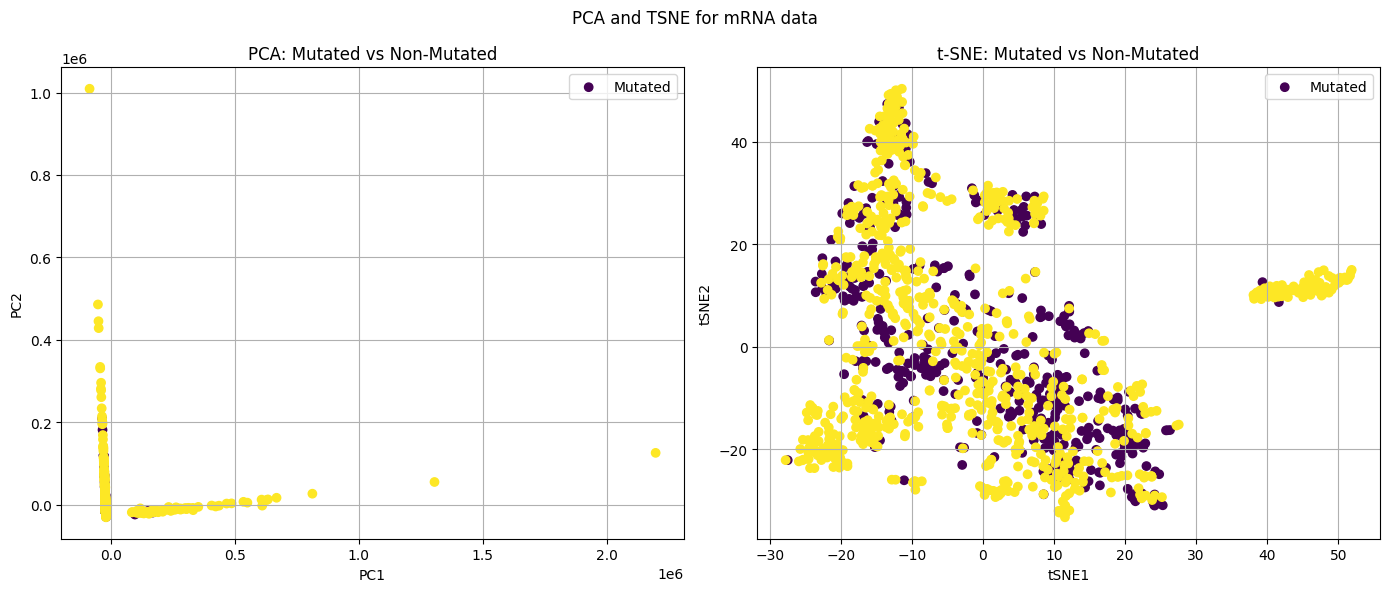

In [25]:
plot_PCA_tsne(mRNA_data_all,mutated_samples,non_mutated_samples,'PCA and TSNE for mRNA data')

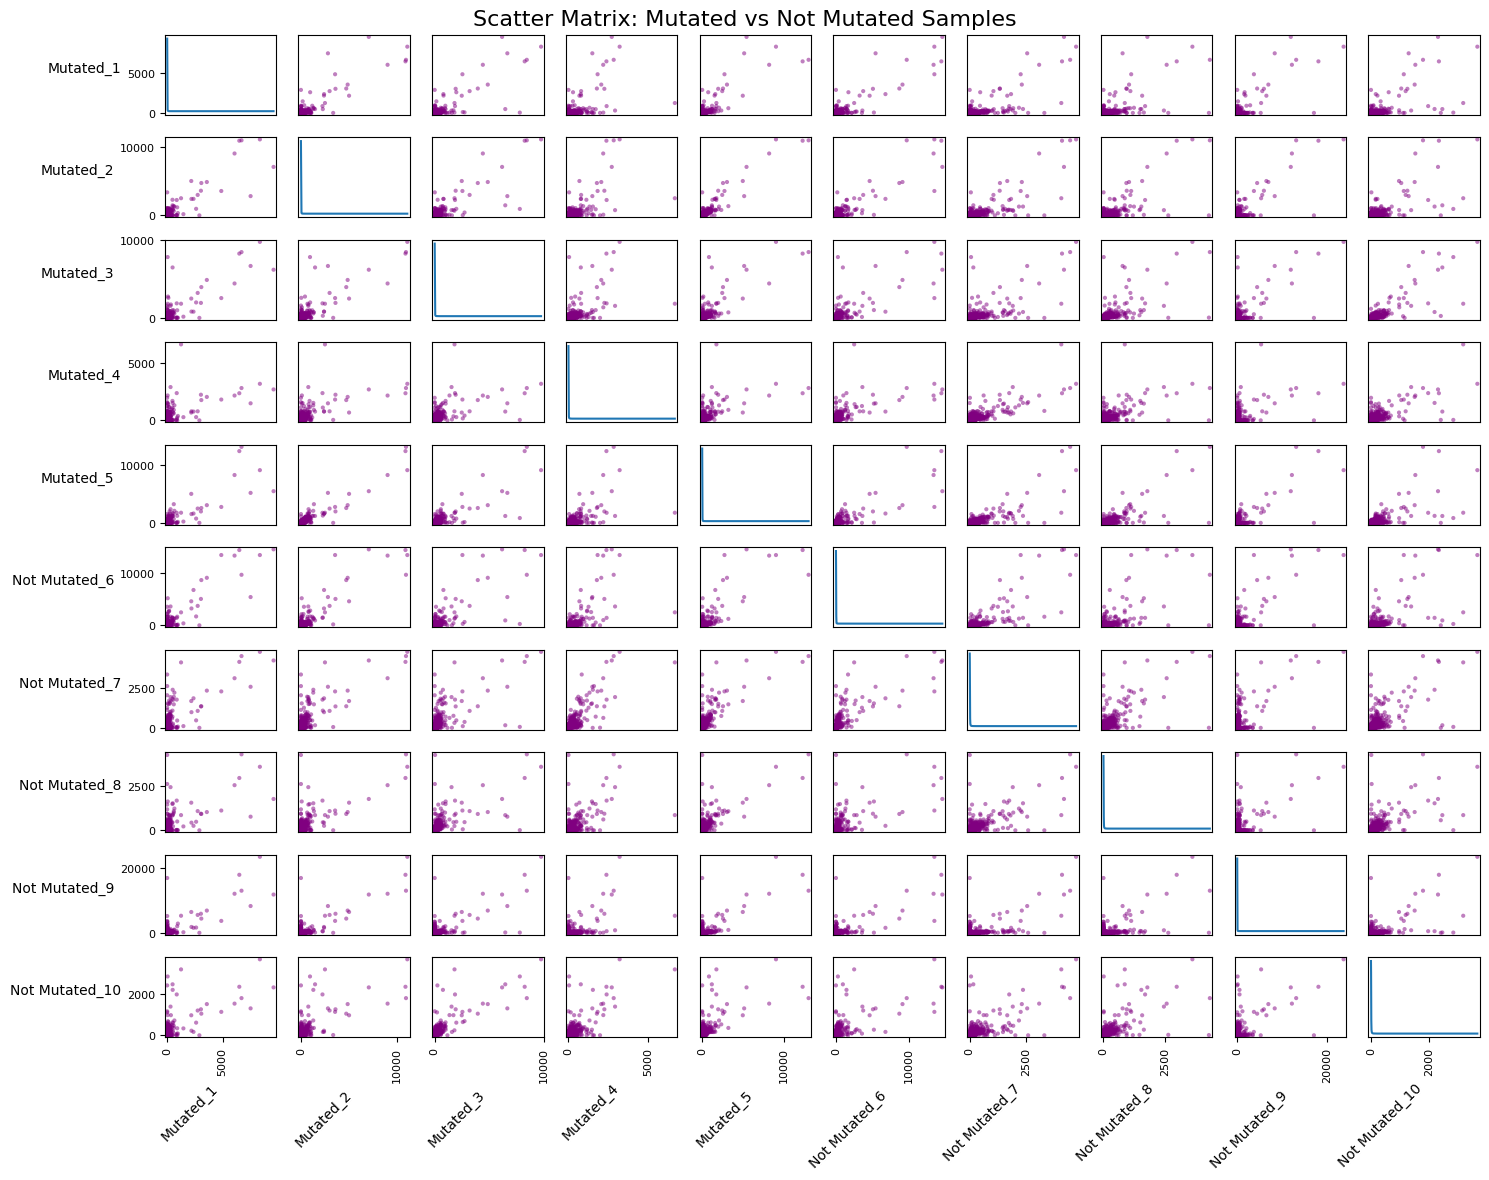

In [26]:
sample_ids = random_samples_mut_100[:5].tolist() + random_samples_non_mut_100[:5].tolist()
sample_mut_non_mut = mRNA.loc[:, sample_ids]

# Rename columns to clearer labels
new_labels = ['Mutated'] * 5 + ['Not Mutated'] * 5
sample_mut_non_mut.columns = [f"{label}_{i+1}" for i, label in enumerate(new_labels)]
axes = scatter_matrix(sample_mut_non_mut, diagonal='kde', figsize=(15, 12), color='purple')

# Rotate x and y axis labels for all subplots
for ax in axes.ravel():
    if ax is not None:
        ax.set_xlabel(ax.get_xlabel(), rotation=45, ha='right')
        ax.set_ylabel(ax.get_ylabel(), rotation=0, ha='right')

plt.suptitle("Scatter Matrix: Mutated vs Not Mutated Samples", fontsize=16)
plt.tight_layout()
plt.show()

## Dataset Building

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [28]:
data= pd.read_csv('../DATA/tcga/final_mrna_data.csv', index_col='Hugo_Symbol')
data.head()

X = data.T
X.head()

mutations = pd.read_csv('../DATA/tcga/final_mutation_data.csv', index_col=0)
mutations.head()

y = mutations['Variant_Type']

In [29]:
# Check that X and y are aligned with the same samples in the same order
assert all(X.index == y.index), "Sample mismatch between features and labels!"


# Train/test split
X_train, X_test, y_train_initial, y_test_initial = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

y_train = y_train_initial.map(lambda x: 0 if x == 'WT' else 1)
y_test = y_test_initial.map(lambda x: 0 if x == 'WT' else 1)

print(f"Training data shape: {X_train.shape}")
print(f"Training labels distribution: {y_train.value_counts()}")
print()
print(f"Testing data shape: {X_test.shape}")
print(f"Testing labels distribution: {y_test.value_counts()}")

Training data shape: (962, 55851)
Training labels distribution: Variant_Type
0    642
1    320
Name: count, dtype: int64

Testing data shape: (241, 55851)
Testing labels distribution: Variant_Type
0    161
1     80
Name: count, dtype: int64


In [30]:
print("Train:",X_train.shape)
print("Test:",X_test.shape)
print("Train:",y_train.shape)
print("Test:",y_test.shape)

Train: (962, 55851)
Test: (241, 55851)
Train: (962,)
Test: (241,)


In [31]:
print(y_train_initial.shape)
print(y_test_initial.shape)

(962,)
(241,)


In [32]:
# Save all the dataframes and arrays
X_train.to_csv('../DATA/tcga/X_train.csv')
X_test.to_csv('../DATA/tcga/X_test.csv')

y_train_initial.to_csv('../DATA/tcga/y_train_initial.csv')
y_test_initial.to_csv('../DATA/tcga/y_test_initial.csv')

y_train.to_csv('../DATA/tcga/y_train.csv')
y_test.to_csv('../DATA/tcga/y_test.csv')
